# 04 — Feature Engineering

## Why this step exists

A machine learning model can't forecast from raw transaction rows - it needs
a regular time series and numeric features that capture the patterns we
found in Notebook 03 (trend, seasonality, recent momentum).

This notebook turns the cleaned transaction data into a **daily revenue
time series with model-ready features**, using `features.build_feature_set()`:

1. **Aggregate** transactions into daily total revenue (no gaps).
2. **Calendar features** - day of week, month, quarter, weekend flag - so the
   model can learn the Nov/Dec seasonality and near-zero Saturday pattern we
   saw in the EDA.
3. **Lag features** - revenue 1/7/14/30 days ago - captures recent momentum
   and "same time last week/month" patterns.
4. **Rolling features** - 7-day and 30-day rolling mean/std - smooths noise
   into a trend signal, without ever leaking the current day's own value.

We deliberately do NOT use customer-level or product-level features here,
since our prediction target is **aggregate daily revenue**, not per-customer
or per-product sales.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from ecommerce_sales_analysis.features import build_feature_set, build_daily_revenue

cleaned = pd.read_csv('../data/processed/cleaned_retail.csv', parse_dates=['InvoiceDate'])
print(f"Cleaned transaction rows: {len(cleaned):,}")

daily = build_daily_revenue(cleaned)
print(f"Daily revenue series: {len(daily)} days, {daily.index.min().date()} to {daily.index.max().date()}")
daily.head()

Cleaned transaction rows: 779,425
Daily revenue series: 739 days, 2009-12-01 to 2011-12-09


,Revenue
Date,
2009-12-01,43894.87
2009-12-02,52762.06
2009-12-03,67413.62
2009-12-04,33913.81
2009-12-05,9803.05


## Why we aggregate to daily revenue first

Our raw data is ~780K individual transaction lines. A forecasting model
predicts a *number per time period*, not a transaction - so we collapse
everything into one row per calendar day. Missing days (no sales recorded,
e.g. holidays) are filled with 0 revenue rather than dropped, so the model
sees a continuous, evenly-spaced time series.

In [2]:
features = build_feature_set(cleaned)
print(f"Feature table shape: {features.shape}")
print(f"Columns: {list(features.columns)}")
features.head()

Feature table shape: (709, 16)
Columns: ['Revenue', 'DayOfWeek', 'Month', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'DayOfYear', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30', 'RollingMean_7', 'RollingStd_7', 'RollingMean_30', 'RollingStd_30']


,Revenue,DayOfWeek,Month,Quarter,IsWeekend,IsMonthStart,IsMonthEnd,DayOfYear,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingStd_7,RollingMean_30,RollingStd_30
Date,,,,,,,,,,,,,,,,
2009-12-31,0.00,3,12,4,0,0,1,365,0.0,0.0,29758.87,43894.87,0.0,0.0,22783.467000,20082.306004
2010-01-01,0.00,4,1,1,0,1,0,1,0.0,0.0,31562.72,52762.06,0.0,0.0,21320.304667,20090.176987
2010-01-02,0.00,5,1,1,1,0,0,2,0.0,0.0,0.00,67413.62,0.0,0.0,19561.569333,19544.836202
2010-01-03,0.00,6,1,1,1,0,0,3,0.0,0.0,11355.19,33913.81,0.0,0.0,17314.448667,17635.551619
2010-01-04,13415.09,0,1,1,0,0,0,4,0.0,0.0,15549.64,9803.05,0.0,0.0,16183.988333,17621.774212


Notice the row count dropped compared to the raw daily series - this is
expected. The longest lookback window (`Lag_30` / `RollingMean_30`) needs
30 prior days of history before it can produce a real value, so the first
~30 rows are dropped rather than filled with fake numbers.

In [3]:
assert features.isna().sum().sum() == 0, "No NaNs should survive into the final feature set"
print(f"Rows dropped due to lag/rolling warm-up: {len(daily) - len(features)}")
print(f"Final model-ready rows: {len(features)}")

Rows dropped due to lag/rolling warm-up: 30
Final model-ready rows: 709


## Sanity-checking a few features visually

The rolling mean should look like a smoothed version of daily revenue - a
cleaner trend line without day-to-day noise. This is a good gut-check that
the feature actually represents what we intend.

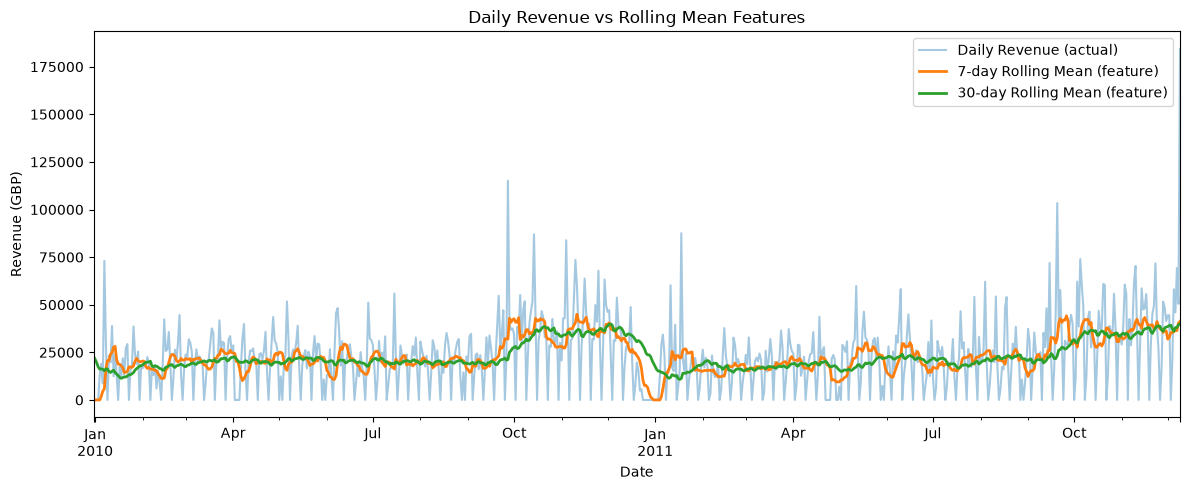

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
features['Revenue'].plot(ax=ax, alpha=0.4, label='Daily Revenue (actual)')
features['RollingMean_7'].plot(ax=ax, label='7-day Rolling Mean (feature)', linewidth=2)
features['RollingMean_30'].plot(ax=ax, label='30-day Rolling Mean (feature)', linewidth=2)
ax.set_title('Daily Revenue vs Rolling Mean Features')
ax.set_ylabel('Revenue (GBP)')
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Correlation of each feature with the target - a quick relevance check
# (not a substitute for real feature importance from a trained model, but
# useful to confirm nothing is obviously broken - e.g. lag_1 should
# correlate reasonably with Revenue).
correlations = features.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)
correlations

Revenue           1.000000
Lag_7             0.604189
Lag_14            0.537679
RollingMean_7     0.402833
Lag_1             0.369386
RollingMean_30    0.347901
RollingStd_7      0.311679
Month             0.292210
DayOfYear         0.289690
Quarter           0.284211
RollingStd_30     0.258486
IsMonthEnd       -0.009392
IsMonthStart     -0.026555
Lag_30           -0.028071
DayOfWeek        -0.370912
IsWeekend        -0.523486
Name: Revenue, dtype: float64

In [6]:
# Save the model-ready feature table for Notebook 05 (Model Training)
from pathlib import Path
features_path = Path('../data/processed/features.csv')
features.to_csv(features_path)
print(f"Saved feature table to {features_path} ({len(features)} rows, {len(features.columns)} columns)")

Saved feature table to ..\data\processed\features.csv (709 rows, 16 columns)


## What we learned

_Fill this in after running the cells above:_
- Which features correlate most strongly with Revenue? Does that match intuition
  (e.g. recent lags and rolling means should correlate more than, say, day-of-year)?
- Does the rolling mean chart look like a believable smoothed trend?
- How many rows did we lose to the lag/rolling warm-up period, and is that
  an acceptable tradeoff given our ~2 years of data?

Next: **Notebook 05 - Model Training**, where we split this feature table
into train/test sets (respecting time order - no shuffling!) and train
forecasting models.